In [32]:
import os
import pandas as pd

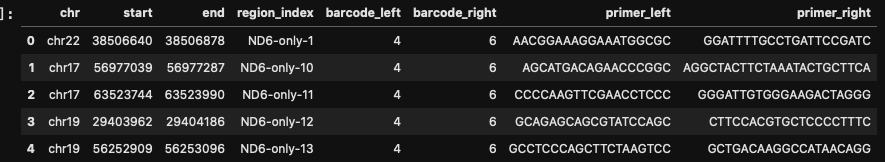

只要有 region_index primer_left primer_right 这三列即可

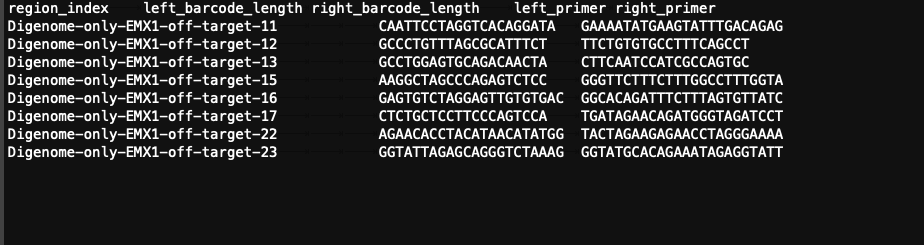

这是从excel直接粘贴到template_for_step.01.csv中的

In [33]:
path = 'template_for_step.01.csv'

In [34]:
df = pd.read_csv(path,sep='\t', header=0)
df.head()

,chr_name,primer_region_start,primer_region_end,region_index,left_barcode_length,right_barcode_length,left_primer,right_primer,strand_info
0,NaN,NaN,NaN,share-new-1,NaN,NaN,TGAATCATGTTCCTCCGAGACT,TTTCTTCTGAGGCCTCTATCTTCT,+
1,NaN,NaN,NaN,share-new-2,NaN,NaN,CTGCATGCGAGAAACCATCATT,ATTTTGCCCAGGCAAAAGCAGG,+
2,NaN,NaN,NaN,share-new-3,NaN,NaN,TGGACTCAGATGGCTTTCTCAC,TATATAACTGGAGAAAGCACCGAG,+
3,NaN,NaN,NaN,share-new-4,NaN,NaN,ACTTTGAGCCACAAGGACAGG,AGATTTTTTGTTCTGAAGATGCCT,+
4,NaN,NaN,NaN,share-new-5,NaN,NaN,CTGAATTGGGGTCTTATTGAGGTA,TAGGGAGTGGGTTAATGCAAAT,+


In [35]:
with open(path + '_R1.fasta','w') as f1,\
open(path + '_R2.fasta','w') as f2:
    for i in df[['region_index','left_primer','right_primer']].values.tolist():
        f1.write('>%s\n%s\n' % (i[0],i[1]))
        f2.write('>%s\n%s\n' % (i[0],i[2]))

In [46]:
# mamba install bowtie=1  
bowtie1_index = "/lustre1/chengqiyi_pkuhpc/zhaohn/1.database/db_genomes/genome_fa/genome_ucsc_hg38/genome_ucsc_hg38.fa.bowtie1_index"
cmd = "bowtie -f -v 3 --seedlen 5 -x {bt1_idx} -1 {r1_fa} -2 {r2_fa} > {bwt_out}".format(bt1_idx=bowtie1_index, r1_fa=path + '_R1.fasta', r2_fa=path + '_R2.fasta', bwt_out = path + '.bwt_out')


print(cmd)

bowtie -f -v 3 --seedlen 5 -x /lustre1/chengqiyi_pkuhpc/zhaohn/1.database/db_genomes/genome_fa/genome_ucsc_hg38/genome_ucsc_hg38.fa.bowtie1_index -1 template_for_step.01.csv_R1.fasta -2 template_for_step.01.csv_R2.fasta > template_for_step.01.csv.bwt_out


In [47]:
os.system(cmd)

# reads processed: 87
# reads with at least one alignment: 73 (83.91%)
# reads that failed to align: 14 (16.09%)
Reported 73 paired-end alignments


0

In [48]:
df_bwtout = pd.read_csv(path + '.bwt_out',sep='\t',names=['region_index','strand','chr','start','seq','align','score','quality'],index_col=None)
df_bwtout1 = df_bwtout.iloc[0::2,:]
df_bwtout1 = df_bwtout1.reset_index()
df_bwtout2 = df_bwtout.iloc[1::2,:]
df_bwtout2 = df_bwtout2.reset_index()


def form_region_index(x):
    return x.split('/')[0]
df_merge = pd.concat([df_bwtout1,df_bwtout2],axis=1)
df_merge.columns = ['index','region_index','strand','chr','start','seq','align','score','quality','index2','region_index2','strand2','chr2','start2','seq2','align2','score2','quality2']
df_merge['tss'] = df_merge['start'] + 1
df_merge['tes'] = df_merge['start2'] + df_merge['seq2'].map(len)
df_merge['true_region_index'] = df_merge['region_index'].map(form_region_index)
df_merge

,index,region_index,strand,chr,start,seq,align,score,quality,index2,...,strand2,chr2,start2,seq2,align2,score2,quality2,tss,tes,true_region_index
0,0,share-new-1/1,+,chr1,58986778,TGAATCATGTTCCTCCGAGACT,IIIIIIIIIIIIIIIIIIIIII,0,NaN,1,...,-,chr1,58986989,AGAAGATAGAGGCCTCAGAAGAAA,IIIIIIIIIIIIIIIIIIIIIIII,0,NaN,58986779,58987013,share-new-1
1,2,share-new-2/1,+,chr15,72679861,CTGCATGCGAGAAACCATCATT,IIIIIIIIIIIIIIIIIIIIII,0,NaN,3,...,-,chr15,72680078,CCTGCTTTTGCCTGGGCAAAAT,IIIIIIIIIIIIIIIIIIIIII,0,NaN,72679862,72680100,share-new-2
2,4,share-new-3/1,+,chr15,76932439,TGGACTCAGATGGCTTTCTCAC,IIIIIIIIIIIIIIIIIIIIII,0,NaN,5,...,-,chr15,76932643,CTCGGTGCTTTCTCCAGTTATATA,IIIIIIIIIIIIIIIIIIIIIIII,0,NaN,76932440,76932667,share-new-3
3,6,share-new-4/1,+,chr6,125054875,ACTTTGAGCCACAAGGACAGG,IIIIIIIIIIIIIIIIIIIII,0,NaN,7,...,-,chr6,125055085,AGGCATCTTCAGAACAAAAAATCT,IIIIIIIIIIIIIIIIIIIIIIII,0,NaN,125054876,125055109,share-new-4
4,8,share-new-6/1,+,chr1,150532522,TAGAGACATGAGGGAAAGGCAG,IIIIIIIIIIIIIIIIIIIIII,0,NaN,9,...,-,chr1,150532740,CTAACGGTGAAGACAAACAGTGAC,IIIIIIIIIIIIIIIIIIIIIIII,0,NaN,150532523,150532764,share-new-6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,136,ND6_new-only13/1,+,chr9,69821434,AGCGGGTGTGTATAAATAGGGG,IIIIIIIIIIIIIIIIIIIIII,0,NaN,137,...,-,chr9,69821610,ATGGAGTGATTTGAACGAGGCC,IIIIIIIIIIIIIIIIIIIIII,0,NaN,69821435,69821632,ND6_new-only13
69,138,ND6_new-only14/1,+,chr11,75560980,AGGATCCAGGCAAGCACCTA,IIIIIIIIIIIIIIIIIIII,0,NaN,139,...,-,chr11,75561182,GGTTTCCTAAATAATCTGCCTCAC,IIIIIIIIIIIIIIIIIIIIIIII,0,NaN,75560981,75561206,ND6_new-only14
70,140,ND6_new-only15/1,+,chr12,95870303,CTCTTTAGGGTTGTTTTGAGGGAA,IIIIIIIIIIIIIIIIIIIIIIII,0,NaN,141,...,-,chr12,95870482,AAATTAGGTGCCGTGTTAGGTG,IIIIIIIIIIIIIIIIIIIIII,0,NaN,95870304,95870504,ND6_new-only15
71,142,ND6_new-only16/1,+,chr15,91376259,CCATGGTGCCAAGACTGTCATA,IIIIIIIIIIIIIIIIIIIIII,0,NaN,143,...,-,chr15,91376435,TCACTTAAAGGGCACAGGTGAG,IIIIIIIIIIIIIIIIIIIIII,0,NaN,91376260,91376457,ND6_new-only16


In [49]:
df_final = df_merge[['true_region_index','chr','tss','tes']]
df_final.sort_values('true_region_index')

,true_region_index,chr,tss,tes
25,ND4_new-only1,chr1,230145841,230146074
32,ND4_new-only10,chr12,50196688,50196909
33,ND4_new-only11,chr14,50843367,50843543
34,ND4_new-only12,chr18,34144750,34144939
35,ND4_new-only13,chr22,33708894,33709141
...,...,...,...,...
3,share-new-4,chr6,125054876,125055109
4,share-new-6,chr1,150532523,150532764
5,share-new-7,chr13,93635311,93635546
6,share-new-8,chr16,66357595,66357800


In [50]:
df_final.to_csv(path + '.bwt_out.targetSeq-form.csv',index=None,sep='\t')